In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Factorización matricial supervisada con MovieLens 32M

El objetivo es predecir la calificación (`rating`) de una película para un usuario. El modelo aprende vectores latentes de usuarios y películas, además de sesgos individuales y un sesgo global:

$$\hat r_{ui} = \mu + b_u + b_i + p_u^\top q_i$$

Se usa una muestra aleatoria por bloques para que la primera ejecución sea manejable. Cambia `SAMPLE_FRACTION` a `1.0` para entrenar con todo `ratings.csv` si tienes memoria y tiempo suficientes.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42
SAMPLE_FRACTION = 1#0.05  # Usa 1.0 para cargar todos los ratings.
CHUNK_SIZE = 1_000_000
EMBEDDING_DIM = 16
BATCH_SIZE = 4096
EPOCHS = 40
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-6
PATIENCE = 2
MIN_DELTA = 1e-4
LIKE_THRESHOLD = 3.8

# Busca ml-32m desde el directorio del notebook, Google Drive o desde la raíz del proyecto.
possible_paths = [
    Path("/content/drive/MyDrive/ml-32m/ratings.csv"),
    Path("/content/drive/My Drive/ml-32m/ratings.csv"),
    Path("../drive/ml-32m/ratings.csv"),
    Path("ml-32m/ratings.csv"),
]
RATINGS_PATH = next((path.resolve() for path in possible_paths if path.exists()), None)
if RATINGS_PATH is None:
    raise FileNotFoundError("No se encontró ml-32m/ratings.csv desde el directorio actual ni en Drive.")

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Archivo: {RATINGS_PATH}")
print(f"Dispositivo: {DEVICE}")

Archivo: /content/drive/MyDrive/ml-32m/ratings.csv
Dispositivo: cuda


In [10]:
if not 0 < SAMPLE_FRACTION <= 1:
    raise ValueError("SAMPLE_FRACTION debe estar en el intervalo (0, 1].")

rating_chunks = []
for chunk_number, chunk in enumerate(
    pd.read_csv(
        RATINGS_PATH,
        usecols=["userId", "movieId", "rating"],
        dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
        chunksize=CHUNK_SIZE,
    )
):
    if SAMPLE_FRACTION < 1:
        chunk = chunk.sample(frac=SAMPLE_FRACTION, random_state=SEED + chunk_number)
    rating_chunks.append(chunk)

ratings = pd.concat(rating_chunks, ignore_index=True)
del rating_chunks
print(f"Ratings cargados: {len(ratings):,}")
display(ratings.head())

Ratings cargados: 32,000,204


,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


In [11]:
# La partición aleatoria conserva usuarios y películas en ambos conjuntos en la mayoría de los casos.
permutation = np.random.default_rng(SEED).permutation(len(ratings))
split_at = int(0.8 * len(permutation))
train_df = ratings.iloc[permutation[:split_at]].copy()
valid_df = ratings.iloc[permutation[split_at:]].copy()

user_ids = np.sort(train_df["userId"].unique())
movie_ids = np.sort(train_df["movieId"].unique())
user_to_index = {user_id: index for index, user_id in enumerate(user_ids)}
movie_to_index = {movie_id: index for index, movie_id in enumerate(movie_ids)}

train_df["user_idx"] = train_df["userId"].map(user_to_index)
train_df["movie_idx"] = train_df["movieId"].map(movie_to_index)
valid_df["user_idx"] = valid_df["userId"].map(user_to_index)
valid_df["movie_idx"] = valid_df["movieId"].map(movie_to_index)
valid_df = valid_df.dropna(subset=["user_idx", "movie_idx"]).copy()

train_users = torch.tensor(train_df["user_idx"].to_numpy(), dtype=torch.long)
train_movies = torch.tensor(train_df["movie_idx"].to_numpy(), dtype=torch.long)
train_targets = torch.tensor(train_df["rating"].to_numpy(), dtype=torch.float32)
valid_users = torch.tensor(valid_df["user_idx"].to_numpy(), dtype=torch.long)
valid_movies = torch.tensor(valid_df["movie_idx"].to_numpy(), dtype=torch.long)
valid_targets = torch.tensor(valid_df["rating"].to_numpy(), dtype=torch.float32)

global_mean = float(train_df["rating"].mean())
print(f"Usuarios: {len(user_ids):,} | Películas: {len(movie_ids):,}")
print(f"Entrenamiento: {len(train_df):,} | Validación (usuarios/películas conocidos): {len(valid_df):,}")
print(f"Promedio de entrenamiento: {global_mean:.3f}")

Usuarios: 200,948 | Películas: 80,250
Entrenamiento: 25,600,163 | Validación (usuarios/películas conocidos): 6,395,294
Promedio de entrenamiento: 3.540


In [12]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim, mean_rating):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, embedding_dim)
        self.movie_factors = nn.Embedding(n_movies, embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.register_buffer("global_mean", torch.tensor(mean_rating, dtype=torch.float32))
        nn.init.normal_(self.user_factors.weight, std=0.05)
        nn.init.normal_(self.movie_factors.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        interaction = (self.user_factors(user_idx) * self.movie_factors(movie_idx)).sum(dim=1)
        return (
            self.global_mean
            + self.user_bias(user_idx).squeeze(1)
            + self.movie_bias(movie_idx).squeeze(1)
            + interaction
        )


def evaluate_rmse(model, users, movies, targets, batch_size=16_384):
    model.eval()
    squared_error_sum = 0.0
    with torch.inference_mode():
        for start in range(0, len(targets), batch_size):
            end = start + batch_size
            batch_users = users[start:end].to(DEVICE)
            batch_movies = movies[start:end].to(DEVICE)
            batch_targets = targets[start:end].to(DEVICE)
            predictions = model(batch_users, batch_movies)
            squared_error_sum += torch.sum((predictions - batch_targets) ** 2).item()
    return float(np.sqrt(squared_error_sum / len(targets)))


model = MatrixFactorization(
    n_users=len(user_ids),
    n_movies=len(movie_ids),
    embedding_dim=EMBEDDING_DIM,
    mean_rating=global_mean,
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_function = nn.MSELoss()
print(model)

MatrixFactorization(
  (user_factors): Embedding(200948, 16)
  (movie_factors): Embedding(80250, 16)
  (user_bias): Embedding(200948, 1)
  (movie_bias): Embedding(80250, 1)
)


In [13]:
history = {"train_mse": [], "valid_rmse": []}
best_valid_rmse = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    shuffled_indices = torch.randperm(len(train_users))
    squared_error_sum = 0.0

    for start in range(0, len(shuffled_indices), BATCH_SIZE):
        batch_indices = shuffled_indices[start : start + BATCH_SIZE]
        batch_users = train_users[batch_indices].to(DEVICE)
        batch_movies = train_movies[batch_indices].to(DEVICE)
        batch_targets = train_targets[batch_indices].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_users, batch_movies)
        loss = loss_function(predictions, batch_targets)
        loss.backward()
        optimizer.step()
        squared_error_sum += loss.item() * len(batch_indices)

    train_mse = squared_error_sum / len(train_users)
    valid_rmse = evaluate_rmse(model, valid_users, valid_movies, valid_targets)
    history["train_mse"].append(train_mse)
    history["valid_rmse"].append(valid_rmse)

    if valid_rmse < best_valid_rmse - MIN_DELTA:
        best_valid_rmse = valid_rmse
        best_epoch = epoch
        best_model_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Época {epoch:02d}/{EPOCHS} | train MSE: {train_mse:.4f} "
        f"| valid RMSE: {valid_rmse:.4f} | mejor: {best_valid_rmse:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping: sin mejora durante {PATIENCE} épocas.")
        break

if best_model_state is None:
    raise RuntimeError("No se pudo guardar un estado válido del modelo.")
model.load_state_dict(best_model_state)
print(f"Mejores pesos restaurados desde la época {best_epoch} (RMSE {best_valid_rmse:.4f}).")

Época 01/40 | train MSE: 1.0289 | valid RMSE: 0.9797 | mejor: 0.9797
Época 02/40 | train MSE: 0.9155 | valid RMSE: 0.9354 | mejor: 0.9354
Época 03/40 | train MSE: 0.8293 | valid RMSE: 0.8918 | mejor: 0.8918
Época 04/40 | train MSE: 0.7631 | valid RMSE: 0.8660 | mejor: 0.8660
Época 05/40 | train MSE: 0.7263 | valid RMSE: 0.8518 | mejor: 0.8518
Época 06/40 | train MSE: 0.7042 | valid RMSE: 0.8427 | mejor: 0.8427
Época 07/40 | train MSE: 0.6888 | valid RMSE: 0.8362 | mejor: 0.8362
Época 08/40 | train MSE: 0.6766 | valid RMSE: 0.8309 | mejor: 0.8309
Época 09/40 | train MSE: 0.6662 | valid RMSE: 0.8265 | mejor: 0.8265
Época 10/40 | train MSE: 0.6567 | valid RMSE: 0.8225 | mejor: 0.8225
Época 11/40 | train MSE: 0.6479 | valid RMSE: 0.8188 | mejor: 0.8188
Época 12/40 | train MSE: 0.6393 | valid RMSE: 0.8153 | mejor: 0.8153
Época 13/40 | train MSE: 0.6311 | valid RMSE: 0.8120 | mejor: 0.8120
Época 14/40 | train MSE: 0.6230 | valid RMSE: 0.8089 | mejor: 0.8089
Época 15/40 | train MSE: 0.6153 | 

RMSE baseline (promedio global): 1.0586
RMSE del modelo (mejores pesos): 0.7800


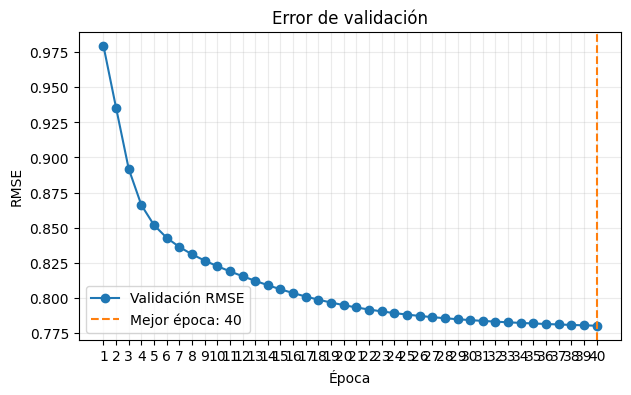

In [14]:
import matplotlib.pyplot as plt

baseline_rmse = float(np.sqrt(np.mean((valid_df["rating"].to_numpy() - global_mean) ** 2)))
final_rmse = evaluate_rmse(model, valid_users, valid_movies, valid_targets)
print(f"RMSE baseline (promedio global): {baseline_rmse:.4f}")
print(f"RMSE del modelo (mejores pesos): {final_rmse:.4f}")

completed_epochs = len(history["valid_rmse"])
plt.figure(figsize=(7, 4))
plt.plot(range(1, completed_epochs + 1), history["valid_rmse"], marker="o", label="Validación RMSE")
plt.axvline(best_epoch, color="tab:orange", linestyle="--", label=f"Mejor época: {best_epoch}")
plt.xlabel("Época")
plt.ylabel("RMSE")
plt.title("Error de validación")
plt.xticks(range(1, completed_epochs + 1))
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 1. Evaluación binaria: Gusta vs. No gusta

Se considera que un usuario disfruta una película cuando su calificación real es de **4 estrellas o más**. Las predicciones continuas del modelo se convierten a clase positiva usando el mismo umbral.

In [15]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

valid_predictions = []
model.eval()
with torch.inference_mode():
    for start in range(0, len(valid_targets), 16_384):
        end = start + 16_384
        batch_users = valid_users[start:end].to(DEVICE)
        batch_movies = valid_movies[start:end].to(DEVICE)
        batch_predictions = model(batch_users, batch_movies)
        valid_predictions.append(batch_predictions.cpu().numpy())

valid_predictions = np.concatenate(valid_predictions)
y_true_binary = (valid_df["rating"].to_numpy() >= LIKE_THRESHOLD).astype(np.int8)
y_pred_binary = (valid_predictions >= LIKE_THRESHOLD).astype(np.int8)
confusion = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

print(f"Umbral para 'Gusta': rating >= {LIKE_THRESHOLD:.1f}")
print("Matriz de confusión (filas = real, columnas = predicción; [No gusta, Gusta]):")
print(confusion)
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Umbral para 'Gusta': rating >= 3.8
Matriz de confusión (filas = real, columnas = predicción; [No gusta, Gusta]):
[[2725153  481550]
 [1176026 2012565]]
Precisión (Precision): 0.8069
Sensibilidad (Recall): 0.6312
F1-Score: 0.7083


In [18]:
import torch

# Definimos la ruta de guardado en tu Drive
checkpoint_path = RATINGS_PATH.parent / "matrix_factorization_model.pt"

# Empaquetamos el estado del modelo junto con los diccionarios de mapeo indispensables
checkpoint = {
    "model_state_dict": model.state_dict(),
    "user_to_index": user_to_index,
    "movie_to_index": movie_to_index,
    "global_mean": global_mean,
    "embedding_dim": EMBEDDING_DIM,
    "like_threshold": LIKE_THRESHOLD
}

# Guardamos el archivo binario
torch.save(checkpoint, checkpoint_path)
print(f"¡Modelo y metadatos exportados exitosamente en: {checkpoint_path}!")

¡Modelo y metadatos exportados exitosamente en: /content/drive/MyDrive/ml-32m/matrix_factorization_model.pt!


## 2. Visualización del espacio latente con PCA

Se proyectan conjuntamente los factores latentes de usuarios y películas a dos componentes principales. La PCA se ajusta con todos los embeddings; para que la gráfica sea legible se muestra una muestra reproducible de cada grupo.

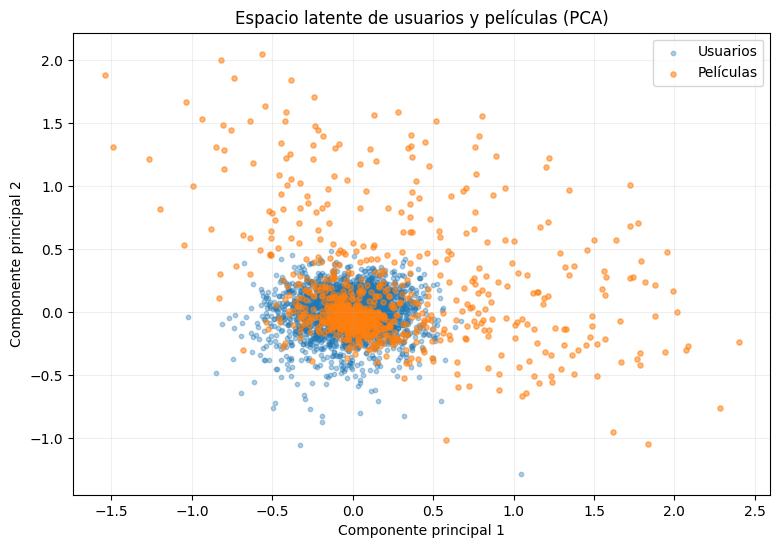

Varianza explicada por las dos componentes: 37.08%


In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

user_factors = model.user_factors.weight.detach().cpu().numpy()
movie_factors = model.movie_factors.weight.detach().cpu().numpy()
all_factors = np.vstack([user_factors, movie_factors])
pca = PCA(n_components=2, random_state=SEED)
all_factors_2d = pca.fit_transform(all_factors)
user_coordinates = all_factors_2d[: len(user_factors)]
movie_coordinates = all_factors_2d[len(user_factors) :]

plot_rng = np.random.default_rng(SEED)
user_sample_size = min(3000, len(user_coordinates))
movie_sample_size = min(3000, len(movie_coordinates))
user_sample = plot_rng.choice(len(user_coordinates), size=user_sample_size, replace=False)
movie_sample = plot_rng.choice(len(movie_coordinates), size=movie_sample_size, replace=False)

plt.figure(figsize=(9, 6))
plt.scatter(
    user_coordinates[user_sample, 0],
    user_coordinates[user_sample, 1],
    s=10,
    alpha=0.35,
    label="Usuarios",
)
plt.scatter(
    movie_coordinates[movie_sample, 0],
    movie_coordinates[movie_sample, 1],
    s=14,
    alpha=0.55,
    label="Películas",
)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Espacio latente de usuarios y películas (PCA)")
plt.grid(alpha=0.2)
plt.legend()
plt.show()
print(f"Varianza explicada por las dos componentes: {pca.explained_variance_ratio_.sum():.2%}")

In [20]:
def recommend_for_user(user_id, top_n=10):
    if user_id not in user_to_index:
        raise ValueError(f"El usuario {user_id} no apareció en los datos de entrenamiento.")

    catalog_path = RATINGS_PATH.parent / "movies.csv"
    catalog = pd.read_csv(catalog_path, usecols=["movieId", "title"])
    catalog["movie_idx"] = catalog["movieId"].map(movie_to_index)
    catalog = catalog.dropna(subset=["movie_idx"]).copy()

    seen_movie_ids = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
    candidates = catalog.loc[~catalog["movieId"].isin(seen_movie_ids)].copy()
    candidate_indices = torch.tensor(candidates["movie_idx"].astype("int64").to_numpy())
    user_index = user_to_index[user_id]

    model.eval()
    score_batches = []
    with torch.inference_mode():
        for start in range(0, len(candidate_indices), 16_384):
            batch_movie_indices = candidate_indices[start : start + 16_384].to(DEVICE)
            batch_users = torch.full_like(batch_movie_indices, user_index)
            scores = model(batch_users, batch_movie_indices).clamp(0.5, 5.0)
            score_batches.append(scores.cpu().numpy())

    candidates["predicted_rating"] = np.concatenate(score_batches)
    return candidates.nlargest(top_n, "predicted_rating")[["movieId", "title", "predicted_rating"]]


example_user_id = int(2000)
print(f"Recomendaciones para usuario {example_user_id}:")
display(recommend_for_user(example_user_id, top_n=10))

Recomendaciones para usuario 2000:


,movieId,title,predicted_rating
17071,89745,"Avengers, The (2012)",4.732463
25102,122914,Avengers: Infinity War - Part II (2019),4.662553
20609,106487,The Hunger Games: Catching Fire (2013),4.625112
764,780,Independence Day (a.k.a. ID4) (1996),4.623834
21357,110102,Captain America: The Winter Soldier (2014),4.588333
12326,59315,Iron Man (2008),4.581847
25101,122912,Avengers: Infinity War - Part I (2018),4.574330
25103,122916,Thor: Ragnarok (2017),4.574245
7925,8636,Spider-Man 2 (2004),4.545177
25092,122892,Avengers: Age of Ultron (2015),4.533526
